# 04 — Crime EDA

**Notebook responsibility:** crime temporal/spatial/compositional analysis — When, Where, What, How it changes. Answers questions 1-4 of the blueprint's final findings framework. No cleaning, no feature engineering — both already done (02, 03). No plot without a stated analytical question behind it.

**Inputs:** `data/interim/crime_cleaned.parquet` (incident-level — hour and category detail), `data/interim/crime_daily.parquet` (community_area × date — trend/hotspot analysis), and Chicago's official community-area boundary file (fetched once, cached — Section 3).

**On weather:** this notebook is crime-only, per the blueprint's own notebook responsibilities table — weather isn't merged until `06_crime_weather_analysis`. `plot_choropleth()` (Section 5.2) is built generically so `06` reuses it unchanged for a weather-*sensitivity* map (e.g. rain-day crime uplift by community area). A literal choropleth of raw weather values would be uniform across all 77 areas — one O'Hare station approximates citywide weather (blueprint limitation) — and would misrepresent precision the data doesn't have.

## 0. Setup

In [3]:
import sys
from pathlib import Path

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

sys.path.append(str(Path.cwd().parent))

from src.config import DATA_INTERIM
from src.data.geo_loader import load_or_fetch_boundaries
from src.features.temporal_features import create_temporal_features, create_date_features
from src.features.spatial_features import add_crime_category
from src.visualization import (
    plot_crime_by_period, plot_seasonal_crime, plot_trend_over_time,
    plot_top_community_areas, plot_community_area_heatmap, plot_coordinate_density, plot_choropleth,
)

pd.set_option("display.max_columns", 60)

_Findings: (fill in after running)_

## 1. Load Data

In [4]:
crime = pd.read_parquet(DATA_INTERIM / "crime_cleaned.parquet")
daily = pd.read_parquet(DATA_INTERIM / "crime_daily.parquet")
print(f"crime_cleaned: {crime.shape}")
print(f"crime_daily:   {daily.shape}")

crime_cleaned: (1210059, 19)
crime_daily:   (140602, 22)


_Findings: (confirm shapes match notebooks 02/03 outputs)_

## 2. Feature Preparation

**Aim:** `crime_daily` carries only `date` — no calendar labels. `crime_cleaned` carries no category/hour detail post-aggregation. Add both via the same functions notebook 03 used — no new logic, no re-cleaning.

In [5]:
daily = create_date_features(daily)
crime = create_temporal_features(crime)
crime = add_crime_category(crime)
print(crime["crime_category"].value_counts())

crime_category
PROPERTY    571341
VIOLENT     378080
OTHER       147149
FRAUD        84420
DRUG         29069
Name: count, dtype: int64


_Findings: (category mix at incident level — should match notebook 03's Section 3 findings)_

## 3. Community Area Boundaries

**Aim:** fetch (or load cached) the official Chicago community-area polygons for the choropleths in Sections 5 and 7. Source: Chicago Data Portal, "Boundaries - Community Areas" (`igwz-8jzy`) — same portal as the crime data, so community area numbering can't drift between the two.

In [6]:
boundaries = load_or_fetch_boundaries()
print(f"Loaded {len(boundaries['features'])} community area polygons.")

Loaded 77 community area polygons.


_Findings: (confirm 77 polygons loaded; fetched fresh or from cache)_

## 4. When — Temporal Patterns

**Question:** does crime concentrate in particular years, months, seasons, days of week, or hours — and how much does day-to-day volume vary, not just average?

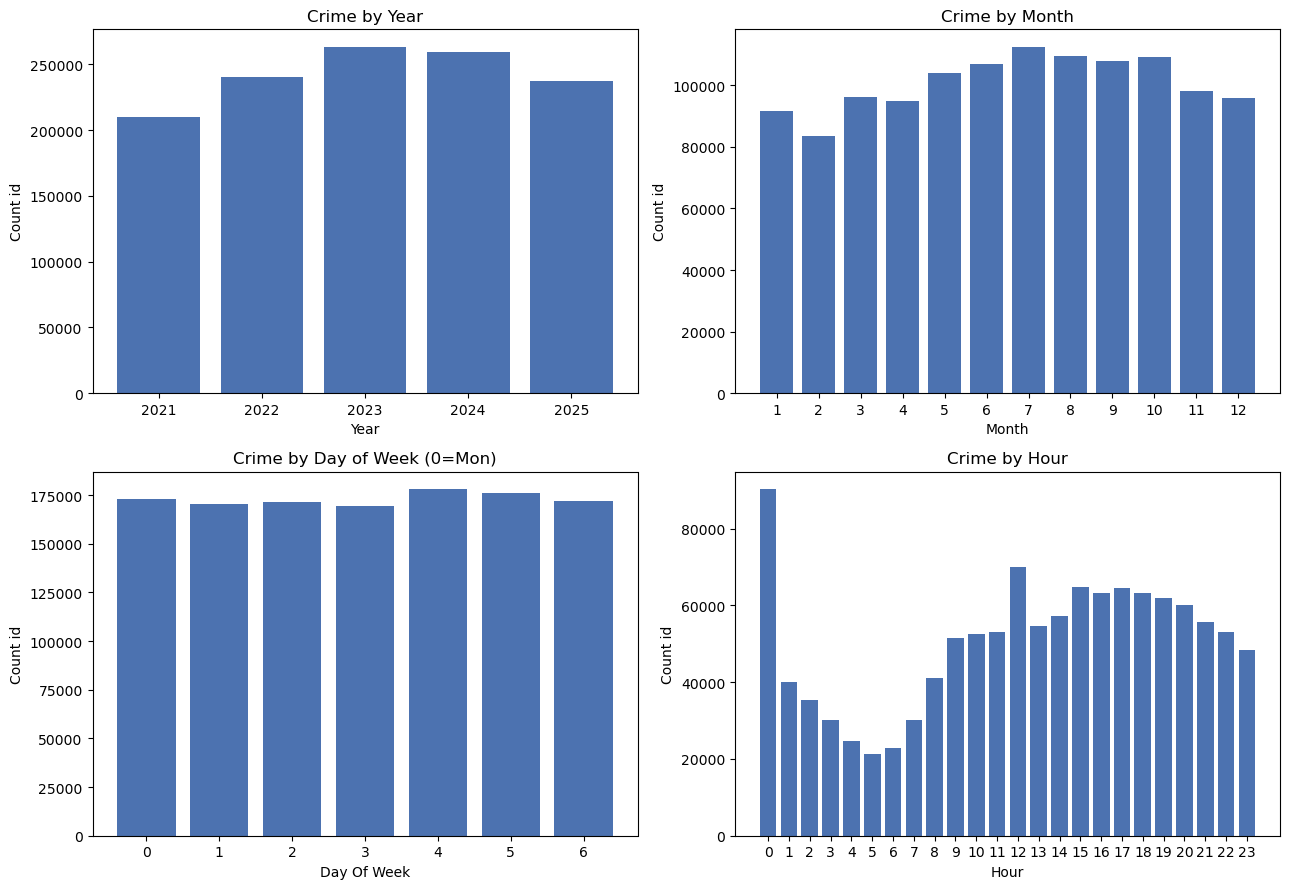

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
plot_crime_by_period(crime, "year", value_col="id", agg="count", ax=axes[0, 0], title="Crime by Year")
plot_crime_by_period(crime, "month", value_col="id", agg="count", ax=axes[0, 1], title="Crime by Month")
plot_crime_by_period(crime, "day_of_week", value_col="id", agg="count", ax=axes[1, 0], title="Crime by Day of Week (0=Mon)")
plot_crime_by_period(crime, "hour", value_col="id", agg="count", ax=axes[1, 1], title="Crime by Hour")
fig.tight_layout()

_Findings: (which year/month/day/hour concentrate crime — any outlier worth a follow-up question in 06?)_

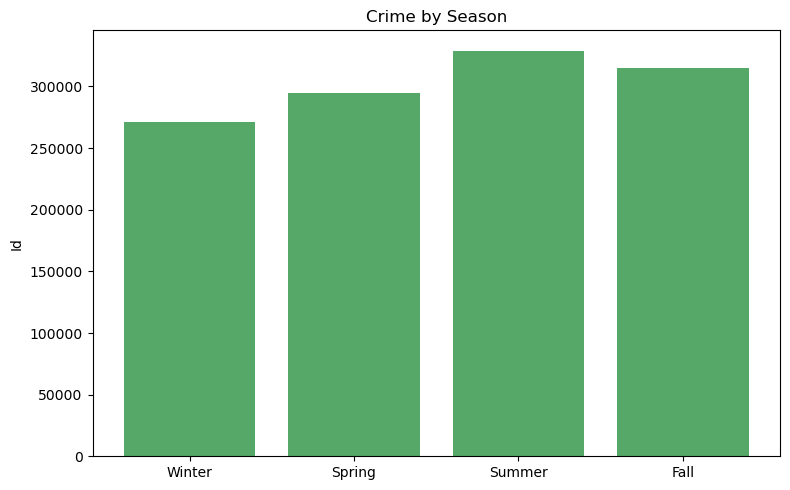

In [8]:
fig = plot_seasonal_crime(crime, value_col="id", agg="count")

_Findings: (seasonal ranking — does it match Chicago's known seasonal crime pattern, i.e. summer higher than winter?)_

count    140602.000000
mean          8.606272
std           7.789339
min           0.000000
25%           3.000000
50%           6.000000
75%          12.000000
max         176.000000
Name: crime_count, dtype: float64
Skew: 1.87


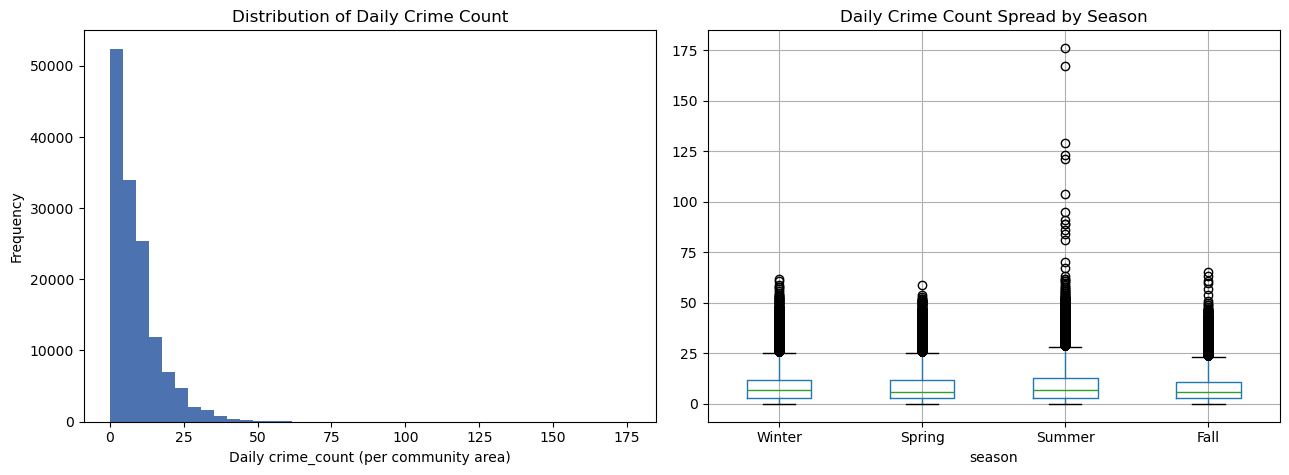

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].hist(daily["crime_count"], bins=40, color="#4C72B0")
axes[0].set_xlabel("Daily crime_count (per community area)")
axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of Daily Crime Count")

season_order = ["Winter", "Spring", "Summer", "Fall"]
daily.boxplot(column="crime_count", by="season", ax=axes[1])
axes[1].set_xticklabels(season_order if list(daily["season"].unique()) else axes[1].get_xticklabels())
axes[1].set_title("Daily Crime Count Spread by Season")
plt.suptitle("")
fig.tight_layout()

print(daily["crime_count"].describe())
print(f"Skew: {daily['crime_count'].skew():.2f}")

_Findings: (is the distribution right-skewed — consistent with most community-area-days being low-crime and a few driving the tail? Does any season show wider spread, not just a higher median?)_

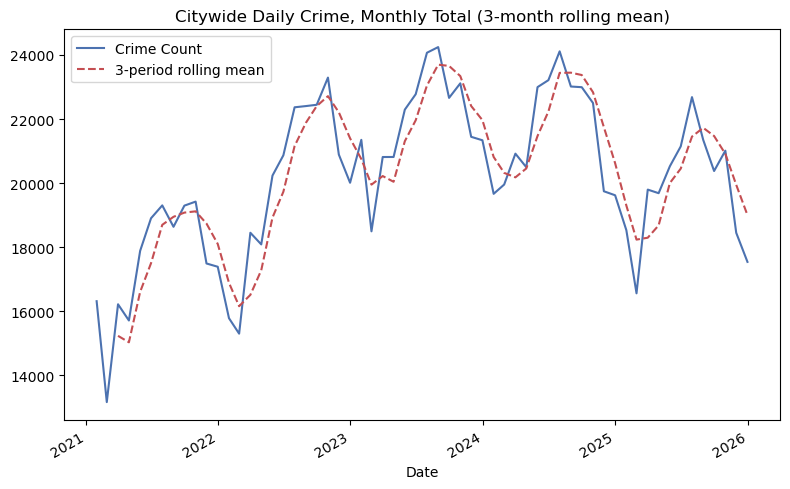

In [10]:
fig = plot_trend_over_time(daily, value_col="crime_count", freq="ME", rolling=3, title="Citywide Daily Crime, Monthly Total (3-month rolling mean)")

_Findings: (overall multi-year trend direction — rising, falling, flat, or seasonal-only with no long-run trend?)_

In [11]:
yearly_total = daily.groupby("year")["crime_count"].sum()
yoy_pct = yearly_total.pct_change().mul(100).round(1)
print(pd.DataFrame({"total_crime": yearly_total, "yoy_pct_change": yoy_pct}))

      total_crime  yoy_pct_change
year                             
2021       209688             NaN
2022       240110            14.5
2023       263409             9.7
2024       259223            -1.6
2025       237629            -8.3


_Findings: (citywide year-over-year change — any year with an unusually large jump or drop worth flagging for the final report's limitations section?)_

## 5. Where — Spatial Patterns

**Question:** which community areas concentrate crime, how is it distributed geographically, and does the pattern hold at the district level too?

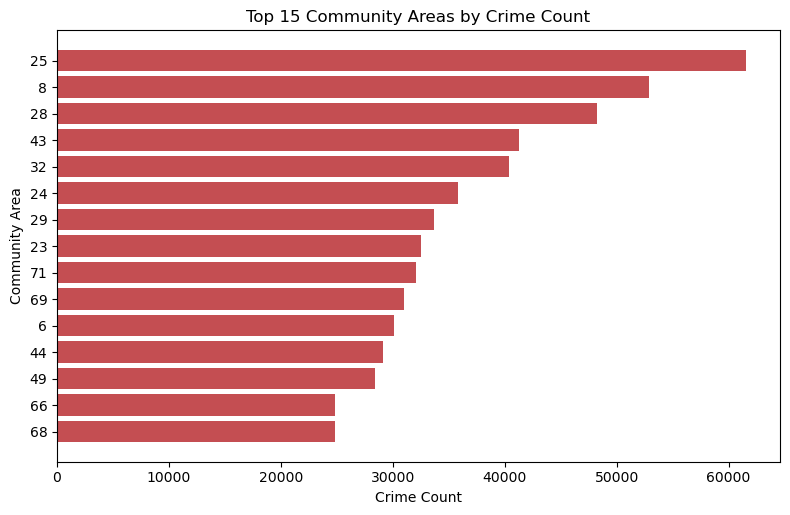

In [12]:
fig = plot_top_community_areas(daily, value_col="crime_count", n=15)

_Findings: (top community areas by total 5-year crime_count — any that stand out disproportionately?)_

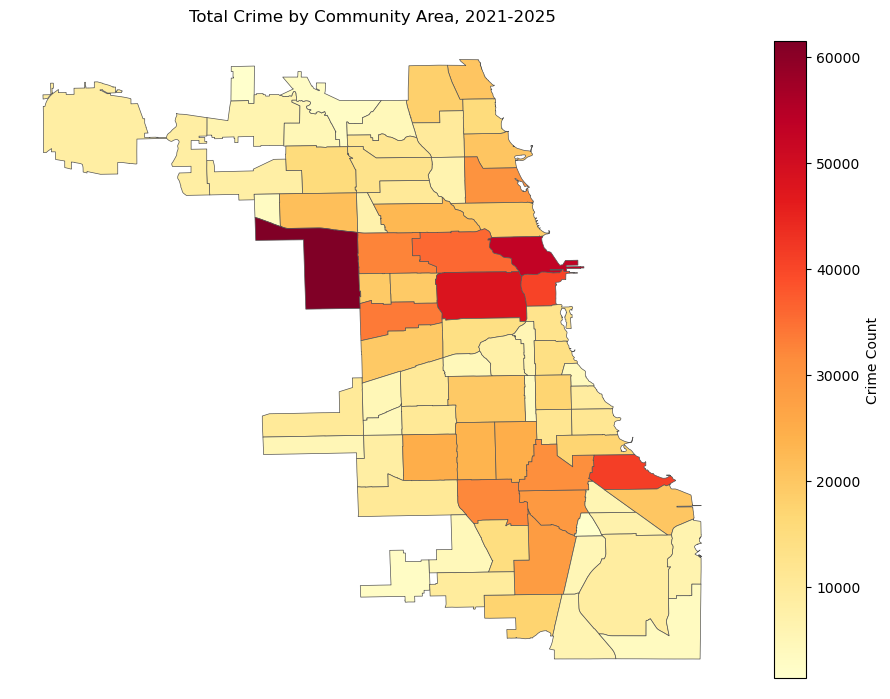

In [13]:
fig = plot_choropleth(daily, boundaries, value_col="crime_count", agg="sum", title="Total Crime by Community Area, 2021-2025")

_Findings: (does the choropleth's spatial pattern match the top-15 bar chart above — any adjacent-area clustering visible on the map that a ranked list can't show?)_

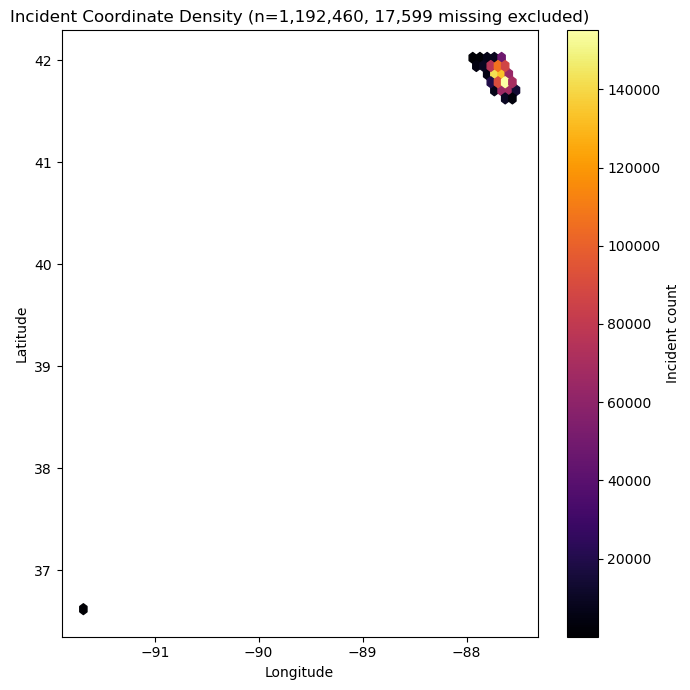

In [14]:
fig = plot_coordinate_density(crime, gridsize=60)

_Findings: (where does incident density concentrate geographically — consistent with the choropleth?)_

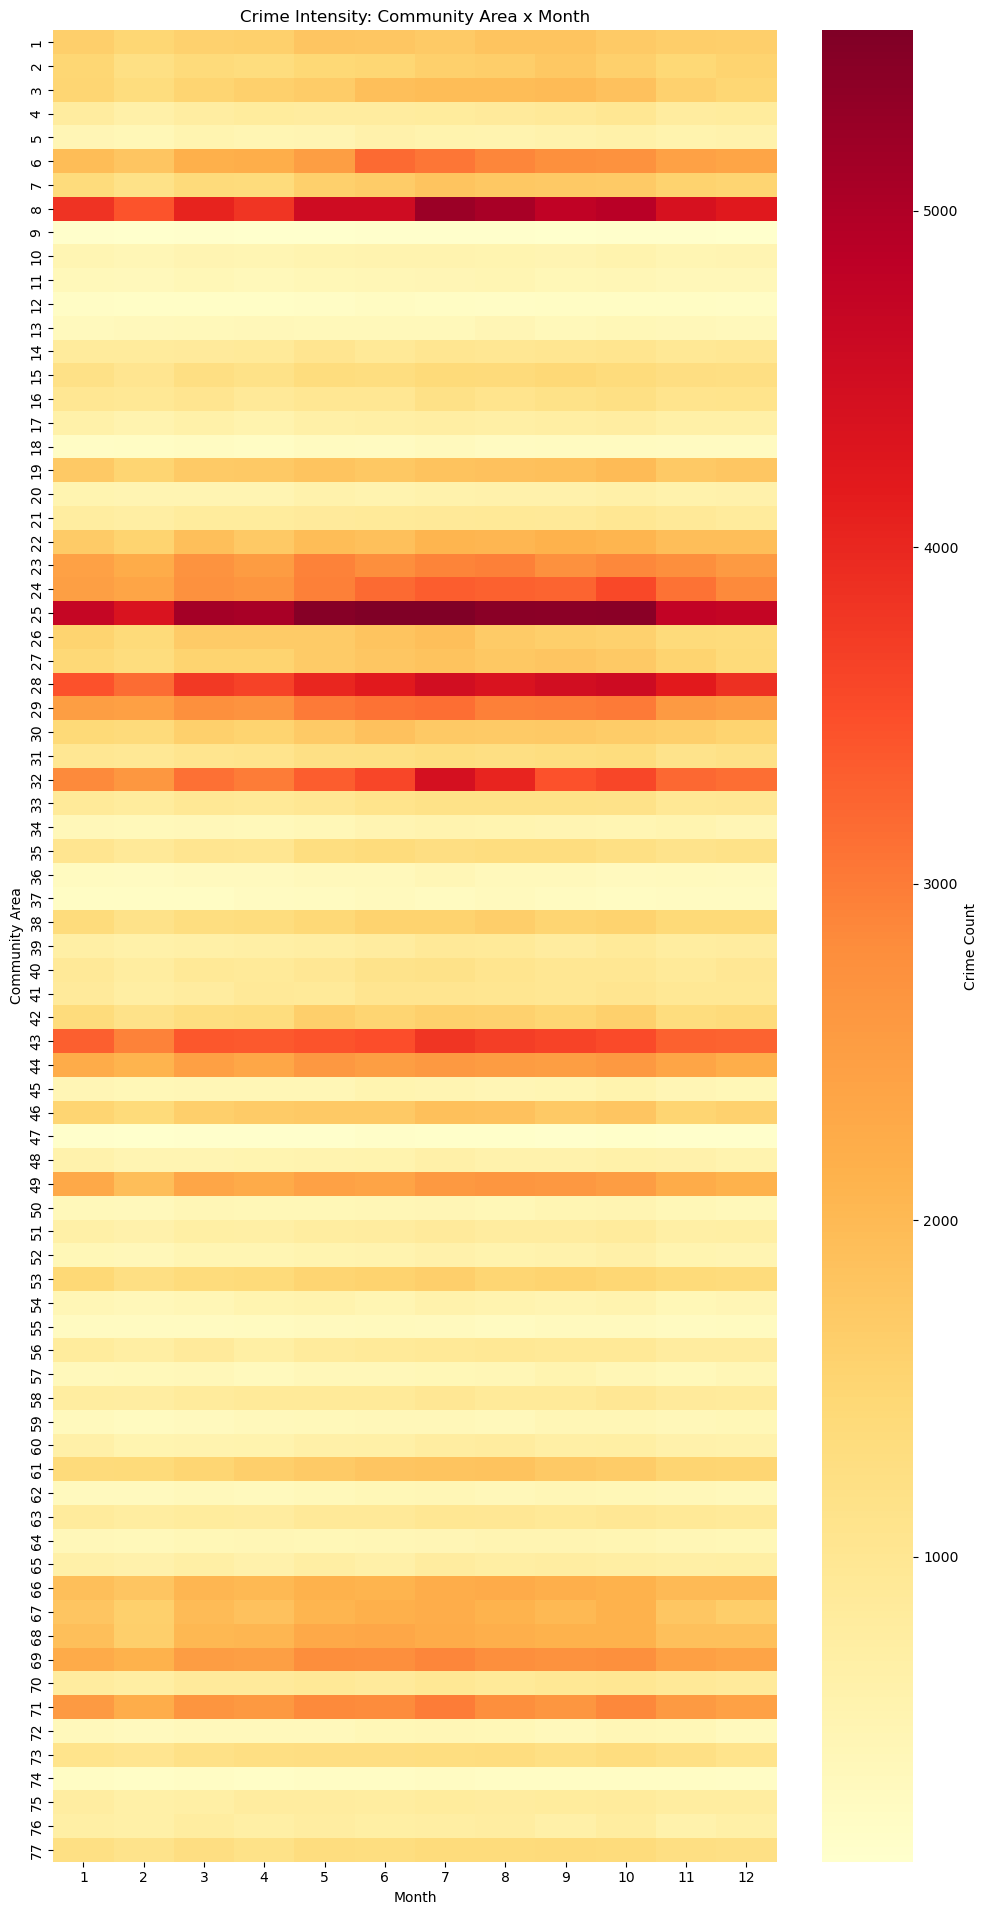

In [15]:
fig = plot_community_area_heatmap(daily, period_col="month", value_col="crime_count")

_Findings: (do high-crime community areas show a flat monthly pattern, or a distinct seasonal spike — sets up the seasonal-by-geography question in Section 7)_

In [16]:
district_totals = crime.groupby("district")["id"].count().sort_values(ascending=False)
print("Top 10 districts by total crime:")
print(district_totals.head(10))

Top 10 districts by total crime:
district
8     77396
6     72729
12    72495
11    68656
4     68380
1     65332
18    62827
19    62501
25    61826
3     61746
Name: id, dtype: int64


_Findings: (secondary spatial unit — do the top districts correspond to the top community areas, or does district-level aggregation surface a different pattern due to district/community-area boundary mismatch?)_

## 6. What — Compositional Patterns

**Question:** what types of crime dominate, how do arrest/domestic rates vary by category, and is the category mix stable across the 5-year window?

In [17]:
category_counts = crime["crime_category"].value_counts()
category_pct = (category_counts / len(crime) * 100).round(1)
print(pd.DataFrame({"count": category_counts, "pct": category_pct}))

print()
print("Top 10 primary_type values:")
print(crime["primary_type"].value_counts().head(10))

                 count   pct
crime_category              
PROPERTY        571341  47.2
VIOLENT         378080  31.2
OTHER           147149  12.2
FRAUD            84420   7.0
DRUG             29069   2.4

Top 10 primary_type values:
primary_type
THEFT                  268953
BATTERY                214461
CRIMINAL DAMAGE        137229
ASSAULT                108863
MOTOR VEHICLE THEFT    100289
DECEPTIVE PRACTICE      84420
OTHER OFFENSE           78298
ROBBERY                 42856
BURGLARY                39926
WEAPONS VIOLATION       39653
Name: count, dtype: int64


_Findings: (dominant category and its share; does OTHER's share here match notebook 03's coverage check?)_

In [18]:
rates = crime.groupby("crime_category").agg(arrest_rate=("arrest", "mean"), domestic_rate=("domestic", "mean"))
rates.round(3)

,arrest_rate,domestic_rate
crime_category,,
DRUG,0.969,0.002
FRAUD,0.027,0.017
OTHER,0.320,0.274
PROPERTY,0.057,0.069
VIOLENT,0.135,0.401


_Findings: (which category has the highest arrest rate — plausible given enforcement patterns for that offense type? Which has the highest domestic rate — consistent with the offense definitions in CRIME_CATEGORY_MAP?)_

crime_category  DRUG  FRAUD  OTHER  PROPERTY  VIOLENT
year                                                 
2021             2.6    8.6   13.4      41.5     33.9
2022             2.0    7.2   12.1      48.3     30.5
2023             2.1    6.7   11.5      49.2     30.5
2024             2.3    6.3   12.0      48.1     31.3
2025             3.1    6.4   12.1      48.0     30.4


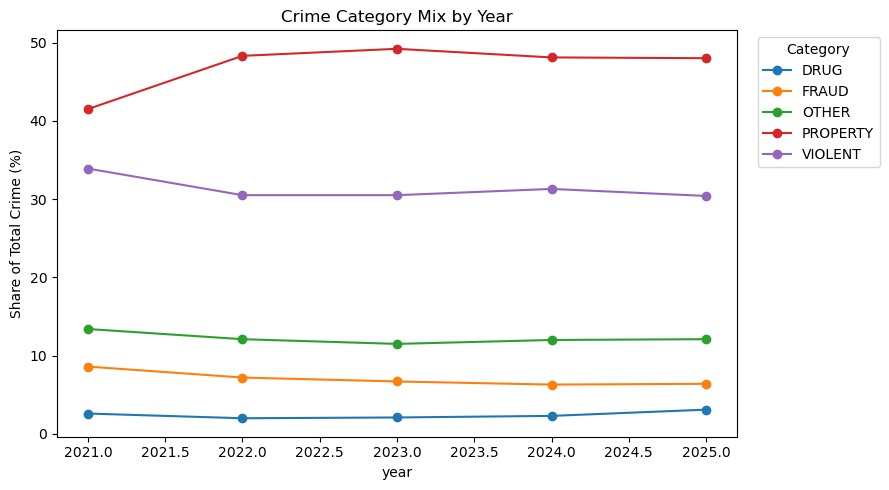

In [19]:
category_by_year = crime.groupby(["year", "crime_category"])["id"].count().unstack(fill_value=0)
category_share_by_year = category_by_year.div(category_by_year.sum(axis=1), axis=0).mul(100).round(1)
print(category_share_by_year)

fig, ax = plt.subplots(figsize=(9, 5))
category_share_by_year.plot(ax=ax, marker="o")
ax.set_ylabel("Share of Total Crime (%)")
ax.set_title("Crime Category Mix by Year")
ax.legend(title="Category", bbox_to_anchor=(1.02, 1), loc="upper left")
fig.tight_layout()

_Findings: (is the category mix stable across 2021-2025, or does one category's share grow/shrink materially — a compositional shift, not just a volume change?)_

## 7. How It Changes — Trends, Hotspots, Emerging/Declining Areas

**Question:** which community areas are persistent hotspots across all five years, which are trending up or down, and does the seasonal pattern from Section 4 hold uniformly across those hotspots?

In [20]:
yearly = daily.groupby(["year", "community_area"])["crime_count"].sum().reset_index()

top10_by_year = {year: set(g.nlargest(10, "crime_count")["community_area"]) for year, g in yearly.groupby("year")}
persistent_hotspots = set.intersection(*top10_by_year.values())
print(f"Community areas in the top 10 every single year (2021-2025): {sorted(persistent_hotspots)}")

Community areas in the top 10 every single year (2021-2025): [8, 23, 24, 25, 28, 29, 32, 43, 71]


_Findings: (persistent hotspots — do they match the top-15 chart / choropleth in Section 5, or does the top-10-every-year filter surface a smaller, more stable set?)_

In [21]:
pivot = yearly.pivot(index="community_area", columns="year", values="crime_count")
first_year, last_year = pivot.columns.min(), pivot.columns.max()
pct_change = ((pivot[last_year] - pivot[first_year]) / pivot[first_year].replace(0, pd.NA) * 100).round(1)

print(f"Top 5 emerging (largest % increase, {first_year} -> {last_year}):")
print(pct_change.sort_values(ascending=False).head(5))
print()
print(f"Top 5 declining (largest % decrease, {first_year} -> {last_year}):")
print(pct_change.sort_values().head(5))

Top 5 emerging (largest % increase, 2021 -> 2025):
community_area
57    61.9
39    53.6
32    52.9
41    48.3
28    48.2
dtype: float64

Top 5 declining (largest % decrease, 2021 -> 2025):
community_area
26   -23.8
47   -23.6
12   -15.0
67   -14.4
53    -8.9
dtype: float64


_Findings: (emerging/declining areas — any large enough % change to warrant a note in the final report, distinct from ordinary year-to-year noise?)_

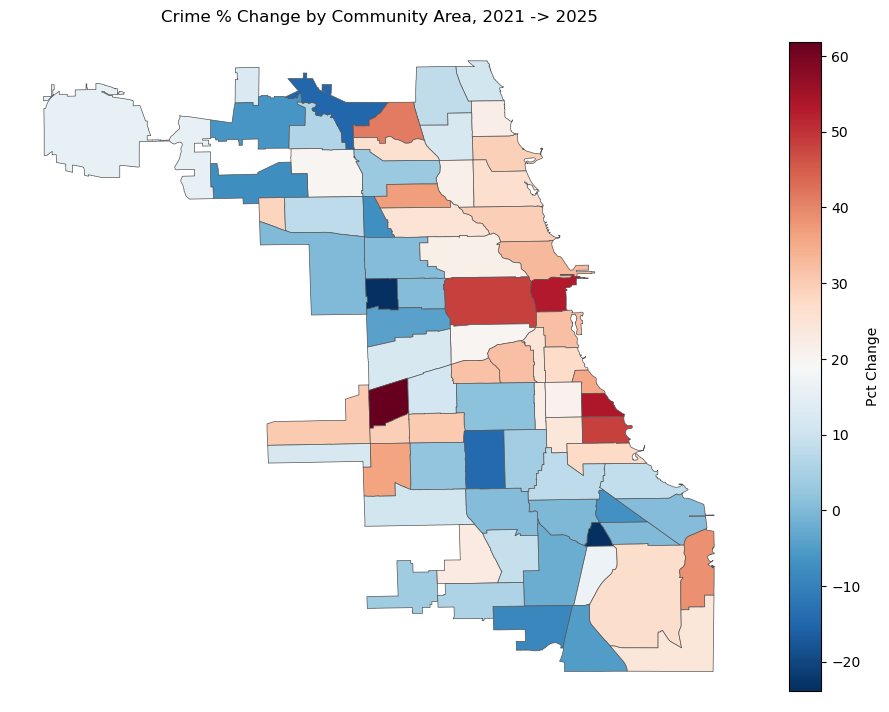

In [22]:
pct_change_df = pct_change.rename("pct_change").reset_index()
fig = plot_choropleth(
    pct_change_df, boundaries, value_col="pct_change", agg="mean", cmap="RdBu_r",
    title=f"Crime % Change by Community Area, {first_year} -> {last_year}",
)

_Findings: (spatial pattern of the emerging/declining % change — do the increases cluster geographically, or scatter across unrelated areas?)_

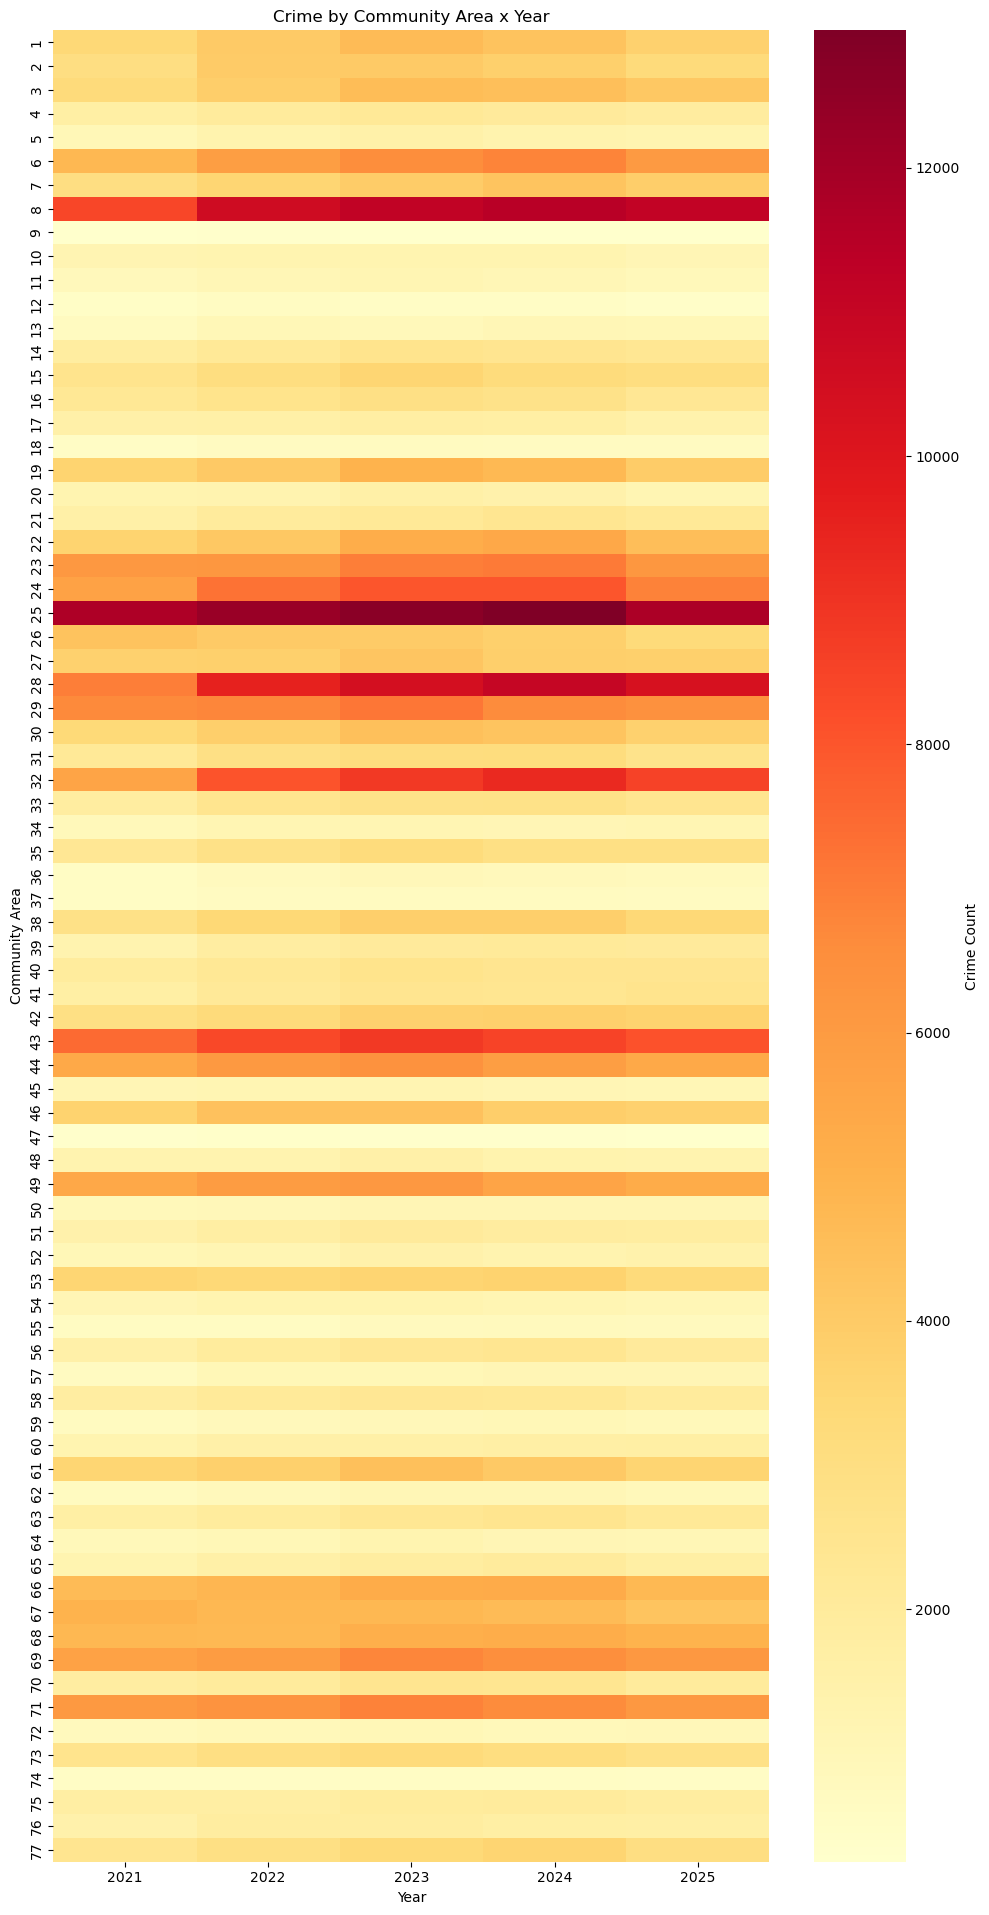

In [23]:
fig = plot_community_area_heatmap(daily, period_col="year", value_col="crime_count", title="Crime by Community Area x Year")

_Findings: (visual confirmation of the persistent-hotspot / emerging-declining findings above — any area whose color changes markedly across the year columns?)_

In [24]:
top8 = daily.groupby("community_area")["crime_count"].sum().nlargest(8).index
seasonal_by_hotspot = (
    daily[daily["community_area"].isin(top8)]
    .groupby(["community_area", "season"])["crime_count"].sum()
    .unstack()
    .reindex(columns=["Winter", "Spring", "Summer", "Fall"])
)
seasonal_share = seasonal_by_hotspot.div(seasonal_by_hotspot.sum(axis=1), axis=0).mul(100).round(1)
print(seasonal_share)

season          Winter  Spring  Summer  Fall
community_area                              
8                 21.8    23.5    28.1  26.7
23                22.3    25.2    26.6  25.9
24                21.5    23.4    27.4  27.7
25                22.4    25.5    26.8  25.3
28                21.8    23.7    27.0  27.4
29                22.1    25.1    27.3  25.4
32                21.4    23.4    29.9  25.4
43                23.1    24.8    26.8  25.4


_Findings: (seasonal-by-geography — do all top-8 hotspot areas share the citywide seasonal pattern from Section 4, or does any area peak in a different season, suggesting a locally distinct driver?)_

## 8. Summary

**When:** _(fill in after running)_
**Where:** _(fill in after running)_
**What:** _(fill in after running)_
**How it changes:** _(fill in after running)_

**Follow-up questions for `06_crime_weather_analysis`:**
- Does the seasonal crime pattern from Section 4 track a specific weather variable, or just the calendar season label?
- Do persistent hotspots (Section 7) show a different weather sensitivity than the citywide average — the weather-sensitivity choropleth planned there reuses `plot_choropleth()` built here.
- Any community area flagged as emerging (Section 7) worth checking against a weather-driven explanation before assuming a non-weather cause?

**Next step:** proceed to `05_weather_analysis.ipynb`.